In [ ]:
# --- Part 1: Imports and Data Setup ---

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
# ImageDataGenerator is not strictly needed for image_dataset_from_directory, but keeping it as it was there
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import pathlib # For handling file paths

print("--- Starting Data Setup ---")

# Download and extract a small flower dataset if not already present
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
archive_path = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True)

# --- FIX STARTS HERE ---
# Adjust data_dir to point to the actual directory containing the class subfolders
# The untarred content is usually in a subfolder named after the archive.
data_dir = pathlib.Path(archive_path) / 'flower_photos'
# --- FIX ENDS HERE ---


# Debugging prints to verify data loading
print(f"DEBUG: Data directory (adjusted): {data_dir}")
print(f"DEBUG: Contents of data_dir (adjusted): {os.listdir(data_dir)}")

# Get the number of classes from the subdirectories
class_names = sorted([item.name for item in data_dir.glob('*') if item.is_dir()])
num_classes = len(class_names)
print(f"Detected {num_classes} classes: {class_names}")

# --- IMPORTANT: Check for number of classes and adjust loss/activation if needed ---
if num_classes == 0:
    raise ValueError("No classes detected! Ensure your data_dir points to a directory containing class subfolders.")
elif num_classes == 1:
    print("\nWARNING: Only one class detected. Switching to 'sigmoid' activation and 'binary_crossentropy' loss.")
    output_activation = 'sigmoid'
    loss_function = 'binary_crossentropy'
else:
    output_activation = 'softmax'
    loss_function = 'sparse_categorical_crossentropy'
# --- END IMPORTANT CHECK ---

IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Load the dataset using image_dataset_from_directory
# This function automatically infers labels from subdirectory names.
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2, # 20% for validation
    subset="training",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

# Normalize pixel values to [0, 1]
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# Prefetching for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("--- Data Setup Complete ---")

--- Starting Data Setup ---
DEBUG: Data directory (adjusted): /root/.keras/datasets/flower_photos/flower_photos
DEBUG: Contents of data_dir (adjusted): ['LICENSE.txt', 'tulips', 'sunflowers', 'daisy', 'roses', 'dandelion']
Detected 5 classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
--- Data Setup Complete ---


In [ ]:
# --- Part 2: Build and Train Fine-tuned Model (Initial Phase) ---

print("\n--- Building the Fine-tuned Model ---")

# Load the pre-trained ResNet50 model, excluding the top (classification) layer
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Freeze all layers in the base model
for layer in base_model.layers:
    layer.trainable = False

# Add new custom layers on top of the frozen base model
x = base_model.output
x = GlobalAveragePooling2D()(x) # Converts the 2D feature maps to a 1D vector
x = Dense(1024, activation='relu')(x) # A fully connected layer for more complex feature combination

# The number of units in the final Dense layer and its activation depends on num_classes
final_output_units = 1 if num_classes == 1 else num_classes
predictions = Dense(final_output_units, activation=output_activation)(x)

# Combine the base model and our new layers into a new model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss=loss_function, # Use the determined loss function
              metrics=['accuracy'])

# Print a summary of the model to see the layers and parameters
print("\n--- Model Summary (Before Fine-tuning) ---")
model.summary()

print("\n--- Training Top Layers ---")
epochs_initial = 10 # You can adjust this based on your dataset and convergence
history_initial = model.fit(
    train_ds,
    epochs=epochs_initial,
    validation_data=val_ds
)

print("--- Initial Training Phase Complete ---")


--- Building the Fine-tuned Model ---
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

--- Model Summary (Before Fine-tuning) ---


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,691,013 (98.00 MB)

 Trainable params: 2,103,301 (8.02 MB)

 Non-trainable params: 23,587,712 (89.98 MB)


--- Training Top Layers ---
Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 696s 7s/step - accuracy: 0.3193 - loss: 1.7050 - val_accuracy: 0.3501 - val_loss: 1.4988
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 728s 7s/step - accuracy: 0.3844 - loss: 1.4636 - val_accuracy: 0.4128 - val_loss: 1.4241
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 678s 7s/step - accuracy: 0.4253 - loss: 1.4043 - val_accuracy: 0.4578 - val_loss: 1.3810
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 662s 7s/step - accuracy: 0.4404 - loss: 1.3724 - val_accuracy: 0.4728 - val_loss: 1.3355
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 660s 7s/step - accuracy: 0.4479 - loss: 1.3434 - val_accuracy: 0.4905 - val_loss: 1.2997
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 685s 7s/step - accuracy: 0.4635 - loss: 1.3171 - val_accuracy: 0.4959 - val_loss: 1.2826
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 666s 7s/step - accuracy: 0.4792 - loss: 1.2951 - val_accuracy: 0.4782 - val_loss: 1.2769
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 679s 7s/step - accuracy: 0.4839 - loss: 1.27

In [ ]:
# --- Part 3: Fine-tuning the Model (Unfreeze and Re-train) ---

print("\n--- Starting Fine-tuning Phase ---")

# Unfreeze some layers of the base model for fine-tuning
# Reset trainability for all layers initially before selective unfreezing
for layer in model.layers:
    layer.trainable = True # Set all to trainable initially

# Freeze layers by index from the beginning of the model
# Freezing the first 100 layers (including some from base_model and initial custom layers) is a common starting point.
# BatchNormalization layers often behave better when not frozen during fine-tuning.
for layer in model.layers[:100]:
   if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# Re-compile the model with a much lower learning rate for fine-tuning
model.compile(optimizer=Adam(learning_rate=0.00001), # Much smaller learning rate
              loss=loss_function, # Use the determined loss function
              metrics=['accuracy'])

print("\n--- Model Summary (After Fine-tuning Layers Unfrozen) ---")
model.summary()

print("\n--- Fine-tuning the entire model (with unfreezing) ---")
epochs_fine_tune = 10 # More epochs for fine-tuning
# Note: Keras `fit` continues from the last state, so epochs are cumulative if you call it again on the same model.
# But for plotting purposes, we'll concatenate histories.
history_fine_tune = model.fit(
    train_ds,
    epochs=epochs_fine_tune,
    validation_data=val_ds
)

print("--- Fine-tuning Phase Complete ---")


--- Starting Fine-tuning Phase ---

--- Model Summary (After Fine-tuning Layers Unfrozen) ---


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,691,013 (98.00 MB)

 Trainable params: 21,572,485 (82.29 MB)

 Non-trainable params: 4,118,528 (15.71 MB)


--- Fine-tuning the entire model (with unfreezing) ---
Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2134s 23s/step - accuracy: 0.3166 - loss: 11.6721 - val_accuracy: 0.2153 - val_loss: 4.6644
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2064s 22s/step - accuracy: 0.7431 - loss: 1.2126 - val_accuracy: 0.2180 - val_loss: 8.1059
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2068s 22s/step - accuracy: 0.9122 - loss: 0.3064 - val_accuracy: 0.2153 - val_loss: 8.7385
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2116s 22s/step - accuracy: 0.9725 - loss: 0.1109 - val_accuracy: 0.2466 - val_loss: 7.3275
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2066s 22s/step - accuracy: 0.9868 - loss: 0.0509 - val_accuracy: 0.2698 - val_loss: 6.1913
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2108s 22s/step - accuracy: 0.9942 - loss: 0.0262 - val_accuracy: 0.3460 - val_loss: 5.2601
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 2071s 23s/step - accuracy: 0.9988 - loss: 0.0163 - val_accuracy: 0.4387 - val_loss: 4.1697
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 20


--- Evaluating Fine-tuned Model ---


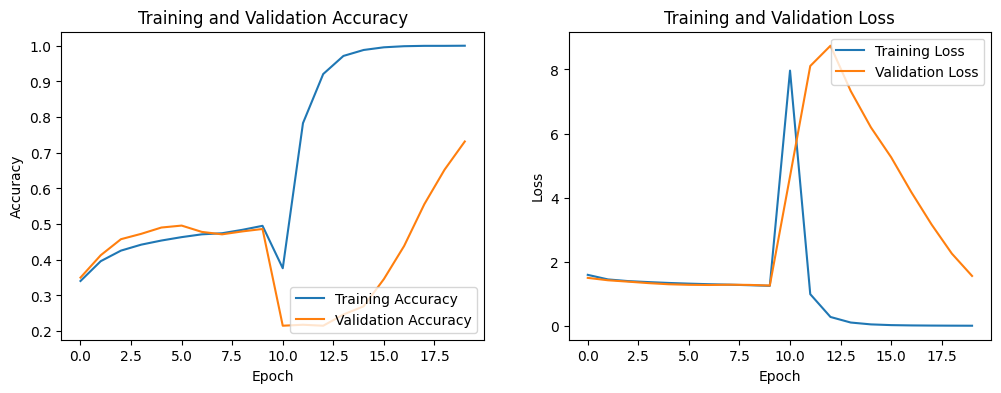


--- Final Model Evaluation ---
23/23 ━━━━━━━━━━━━━━━━━━━━ 130s 6s/step - accuracy: 0.7298 - loss: 1.6810
Validation Loss: 1.5590
Validation Accuracy: 0.7316
--- Evaluation and Plotting Complete ---


In [ ]:
# --- Part 4: Evaluate Fine-tuned Model and Plot History ---

print("\n--- Evaluating Fine-tuned Model ---")

# Combine history for plotting
acc = history_initial.history['accuracy'] + history_fine_tune.history['accuracy']
val_acc = history_initial.history['val_accuracy'] + history_fine_tune.history['val_accuracy']

loss = history_initial.history['loss'] + history_fine_tune.history['loss']
val_loss = history_initial.history['val_loss'] + history_fine_tune.history['val_loss']

# Plot training and validation accuracy and loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')


plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

# Evaluate the fine-tuned model on the validation set
print("\n--- Final Model Evaluation ---")
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

print("--- Evaluation and Plotting Complete ---")


--- Generating Classification Report and Confusion Matrix ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step

--- Classification Report ---
              precision    recall  f1-score   support

       daisy       0.

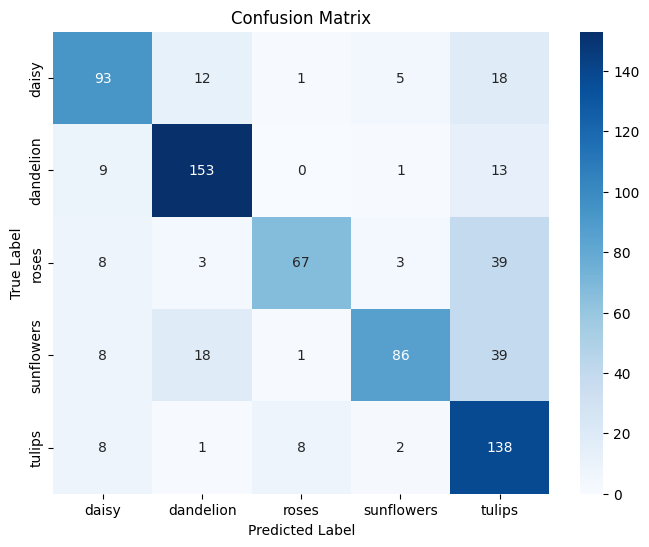

--- Classification Report and Confusion Matrix Generation Complete ---


In [ ]:
# --- Part 5: Generate Classification Report and Confusion Matrix ---

print("\n--- Generating Classification Report and Confusion Matrix ---")

# Get true labels and predictions
y_true = []
y_pred = []
for images, labels in val_ds:
    y_true.extend(labels.numpy())
    preds = model.predict(images)
    # If num_classes is 1, predictions will be probabilities, not one-hot encoded
    if num_classes == 1:
        y_pred.extend((preds > 0.5).astype(int).flatten()) # For binary, threshold at 0.5
    else:
        y_pred.extend(np.argmax(preds, axis=1))

# Check unique labels present in the actual validation data
unique_labels_in_y_true = np.unique(y_true).tolist()

# Define target names and labels for classification_report and confusion_matrix
if num_classes == 1:
    # If the system detected only one class (num_classes == 1)
    # AND the actual validation data also only contains one unique label (e.g., all 0s)
    if len(unique_labels_in_y_true) <= 1:
        print("Note: Skipping detailed classification report/confusion matrix.")
        print("This is because the validation dataset appears to contain only one unique class label.")
        # We cannot generate a meaningful report or matrix for a single class.
        # This is the fix for the ValueError you encountered.
        skip_report_and_matrix = True
    else:
        # This branch handles the rare case where num_classes was determined as 1,
        # but y_true somehow contains both 0s and 1s (e.g., mislabeling or odd split)
        report_target_names = ['Class 0', 'Class 1']
        report_labels = [0, 1]
        skip_report_and_matrix = False
else: # num_classes > 1 (multi-class)
    report_target_names = class_names
    report_labels = list(range(num_classes)) # Labels should be 0, 1, ..., num_classes-1
    skip_report_and_matrix = False

if not skip_report_and_matrix:
    print("\n--- Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=report_target_names, labels=report_labels, zero_division=0))

    print("\n--- Confusion Matrix ---")
    cm = confusion_matrix(y_true, y_pred, labels=report_labels) # Specify labels for consistent order
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=report_target_names, yticklabels=report_target_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()
else:
    print("Classification report and confusion matrix skipped as per logic for single-class validation data.")

print("--- Classification Report and Confusion Matrix Generation Complete ---")

In [ ]:
# --- Part 6: Build and Train Baseline Model ---

print("\n--- Building and Training a Simple Baseline CNN from Scratch ---")

# This part of the code relies on `num_classes` and `output_activation`
# being correctly set in Part 1. With the fix, `num_classes` should be 5.
final_output_units_baseline = 1 if num_classes == 1 else num_classes

baseline_model = tf.keras.Sequential([
    # Rescaling layer to normalize pixel values from 0-255 to 0-1
    tf.keras.layers.Rescaling(1./255, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    # Simple convolutional blocks
    tf.keras.layers.Conv2D(16, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    # Flatten the output from the convolutional layers
    tf.keras.layers.Flatten(),

    # Dense layers for classification
    tf.keras.layers.Dense(128, activation='relu'),

    # Final dense layer with the correct number of units and activation for the problem
    tf.keras.layers.Dense(final_output_units_baseline, activation=output_activation)
])

baseline_model.compile(optimizer='adam',
                       loss=loss_function, # Correct loss function based on num_classes
                       metrics=['accuracy'])

print("\n--- Baseline Model Summary ---")
baseline_model.summary()

epochs_baseline = 20 # Train for more epochs as it's learning from scratch
history_baseline = baseline_model.fit(
    train_ds,
    epochs=epochs_baseline,
    validation_data=val_ds
)

print("\n--- Baseline Model Training Complete ---")


--- Building and Training a Simple Baseline CNN from Scratch ---

--- Baseline Model Summary ---


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     6,422,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,446,885 (24.59 MB)

 Trainable params: 6,446,885 (24.59 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 158s 2s/step - accuracy: 0.2449 - loss: 1.6007 - val_accuracy: 0.2398 - val_loss: 1.6056
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 158s 2s/step - accuracy: 0.2588 - loss: 1.5998 - val_accuracy: 0.2398 - val_loss: 1.6030
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 151s 2s/step - accuracy: 0.2588 - loss: 1.5972 - val_accuracy: 0.2398 - val_loss: 1.6026
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.2588 - loss: 1.5963 - val_accuracy: 0.2398 - val_loss: 1.6019
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 151s 2s/step - accuracy: 0.2588 - loss: 1.5942 - val_accuracy: 0.2398 - val_loss: 1.6019
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step - accuracy: 0.2588 - loss: 1.5939 - val_accuracy: 0.2398 - val_loss: 1.6019
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 203s 2s/step - accuracy: 0.2588 - loss: 1.5939 - val_accuracy: 0.2398 - val_loss: 1.6019
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - accuracy: 0.2588 - loss: 1.5939 - val_accuracy: 0.2398 - v

In [ ]:
# --- Part 7: Evaluate Baseline Model and Final Comparison ---

print("\n--- Baseline Model Evaluation ---")
loss_baseline, accuracy_baseline = baseline_model.evaluate(val_ds)
print(f"Baseline Validation Loss: {loss_baseline:.4f}")
print(f"Baseline Validation Accuracy: {accuracy_baseline:.4f}")

# Compare fine-tuned vs. baseline
print("\n--- Comparison of Fine-tuned vs. Baseline Model ---")
# 'accuracy' variable from Part 4 is the fine-tuned model's accuracy
print(f"Fine-tuned Model Accuracy: {accuracy:.4f}")
print(f"Baseline Model Accuracy: {accuracy_baseline:.4f}")

print("\n--- Script Execution Complete ---")


--- Baseline Model Evaluation ---
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 503ms/step - accuracy: 0.2269 - loss: 1.6064
Baseline Validation Loss: 1.6019
Baseline Validation Accuracy: 0.2398

--- Comparison of Fine-tuned vs. Baseline Model ---
Fine-tuned Model Accuracy: 0.7316
Baseline Model Accuracy: 0.2398

--- Script Execution Complete ---
